# Assignment 1 ml foundations: data prep

By Habib Rahal  

This notebook does the data preparation and feature engineering for the bank dataset. The goal of the campaign is to predict if a client would subscribe to a term deposit. we are going to work through the task 1 by 1.


## Task 1: Identifying the Prediction Target


In [2]:
import pandas as pd
import numpy as np

# sklearn tools
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import VarianceThreshold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# imbalanced data tools
from imblearn.over_sampling import RandomOverSampler

# data path inside repo root
DATA_PATH = "archive/bank-additional.csv" 


In [3]:
# read csv file
df = pd.read_csv(DATA_PATH, sep=';')

# basic shape
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
# show first rows
df.head()

Shape: (4119, 21)

Columns: ['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'y']


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,30,blue-collar,married,basic.9y,no,yes,no,cellular,may,fri,...,2,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no
1,39,services,single,high.school,no,no,no,telephone,may,fri,...,4,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
2,25,services,married,high.school,no,yes,no,telephone,jun,wed,...,1,999,0,nonexistent,1.4,94.465,-41.8,4.962,5228.1,no
3,38,services,married,basic.9y,no,unknown,unknown,telephone,jun,fri,...,3,999,0,nonexistent,1.4,94.465,-41.8,4.959,5228.1,no
4,47,admin.,married,university.degree,no,yes,no,cellular,nov,mon,...,1,999,0,nonexistent,-0.1,93.200,-42.0,4.191,5195.8,no


The column that should be the prediction target is y. It indicates whether the client subscribed to a term deposit yes/no. thats how we predict whether the client subscribes given the information at contact time.

The two other columns could look like targets but should not be used:

- p of outcome: this is the outcome of the previous marketing campaign. It describes the past, not the current campaign outcome. So it is an input feature, not the target we want to predict.
- duration: call duration in seconds for the current contact. At the moment we would make a prediction (e.g. at the start of the call), we do not know the duration. Using it would leak information about the outcome, because longer calls often mean the client subscribed. Which means its a temporal leakage so it should not be the target and later we should not use it as a feature either. 

## Task 2: Data Loading and Exploration

Next we load the data  and look at it's structure: how many rows and columns, what types, and how the target is distributed. I also checked for missing values including unknowns and plot a some numerical and categorical variables to see what we are working with.

In [4]:
# load again for this task
df = pd.read_csv(DATA_PATH, sep=';')

# shape and dtypes
print("Shape:", df.shape)
print("\nData types:")
print(df.dtypes)

df.info()

Shape: (4119, 21)

Data types:
age                 int64
job                object
marital            object
education          object
default            object
housing            object
loan               object
contact            object
month              object
day_of_week        object
duration            int64
campaign            int64
pdays               int64
previous            int64
poutcome           object
emp.var.rate      float64
cons.price.idx    float64
cons.conf.idx     float64
euribor3m         float64
nr.employed       float64
y                  object
dtype: object
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4119 entries, 0 to 4118
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             4119 non-null   int64  
 1   job             4119 non-null   object 
 2   marital         4119 non-null   object 
 3   education       4119 non-null   object 
 4   default         4119 non-nu

In [6]:
# numeric and categorical columns
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = df.select_dtypes(include=["object"]).columns.tolist()

print("Numerical columns:", numeric_cols)
print("\nCategorical columns:", cat_cols)
# describe numeric, categorical
print("\nSummary statistics (numerical):")
display(df[numeric_cols].describe())

print("\nSummary statistics (categorical):")
display(df[cat_cols].describe())

Numerical columns: ['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']

Categorical columns: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome', 'y']

Summary statistics (numerical):


,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000
mean,40.113620,256.788055,2.537266,960.422190,0.190337,0.084972,93.579704,-40.499102,3.621356,5166.481695
std,10.313362,254.703736,2.568159,191.922786,0.541788,1.563114,0.579349,4.594578,1.733591,73.667904
min,18.000000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.635000,4963.600000
25%,32.000000,103.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.334000,5099.100000
50%,38.000000,181.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.000000,317.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,88.000000,3643.000000,35.000000,999.000000,6.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000



Summary statistics (categorical):


,job,marital,education,default,housing,loan,contact,month,day_of_week,poutcome,y
count,4119,4119,4119,4119,4119,4119,4119,4119,4119,4119,4119
unique,12,4,8,3,3,3,2,10,5,3,2
top,admin.,married,university.degree,no,yes,no,cellular,may,thu,nonexistent,no
freq,1012,2509,1264,3315,2175,3349,2652,1378,860,3523,3668


In [7]:
print("Target (y) value counts:")
print(df["y"].value_counts())
print("\nProportions:")
print(df["y"].value_counts(normalize=True))

Target (y) value counts:
y
no     3668
yes     451
Name: count, dtype: int64

Proportions:
y
no     0.890507
yes    0.109493
Name: proportion, dtype: float64


The target is clearly imbalanced: most clients did not subscribe ("no"). So we will need to be careful later with metrics (accuracy can be misleading) and we might use resampling on the training set only.

In [8]:
# count NaN values
print("NaN counts per column:")
print(df.isna().sum())

# count "unknown" labels
print("\n'unknown' counts in categorical columns:")
for col in cat_cols:
    n = (df[col] == "unknown").sum()
    if n > 0:
        print(col, n)

NaN counts per column:
age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

'unknown' counts in categorical columns:
job 39
marital 11
education 167
default 803
housing 105
loan 105


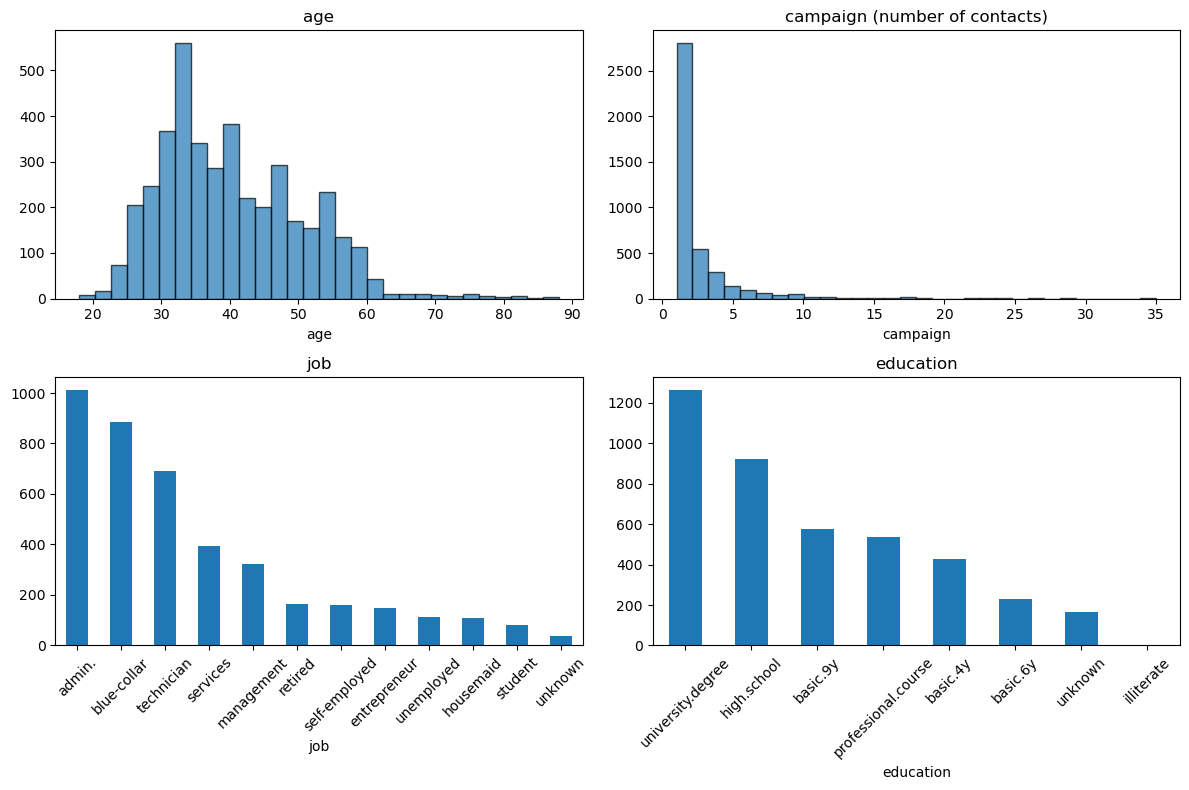

In [9]:
import matplotlib.pyplot as plt

# 2x2 subplot grid
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

#histograms, bar plots
axes[0, 0].hist(df["age"], bins=30, edgecolor="black", alpha=0.7)
axes[0, 0].set_title("age")
axes[0, 0].set_xlabel("age")
axes[0, 1].hist(df["campaign"], bins=30, edgecolor="black", alpha=0.7)
axes[0, 1].set_title("campaign (number of contacts)")
axes[0, 1].set_xlabel("campaign")
df["job"].value_counts().plot(kind="bar", ax=axes[1, 0])
axes[1, 0].set_title("job")
axes[1, 0].tick_params(axis="x", rotation=45)
df["education"].value_counts().plot(kind="bar", ax=axes[1, 1])
axes[1, 1].set_title("education")
axes[1, 1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

we stil need to consider the duration variable: "call duration in seconds". We already said in Task 1 that it is not available at prediction time because we don't know how long the call will last when we make the prediction. So it would cause data leakage if we use it as a feature. Ill exclude it when I build the model later.

## Task 3: Data Splitting

We split the data into training, validation, and test sets before any preprocessing that learns from the data. That way we avoid data leakage: no information from validation or test is used when we fit imputation, encoding, or scaling later. We use stratified splitting on the target so that each set keeps roughly the same proportion of yes/no subscriptions, which is important because the positive class is rare.

In [10]:
from sklearn.model_selection import train_test_split

# drop target and leakage
X = df.drop(columns=["y", "duration"])
# map yes/no to 1/0
y = df["y"].map({"no": 0, "yes": 1})

# first split: train and temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, stratify=y, random_state=42
)

# second split: val and test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

# show sizes and class ratios
print("Train:", X_train.shape[0], "samples")
print("Validation:", X_val.shape[0], "samples")
print("Test:", X_test.shape[0], "samples")
print("\nTrain class proportions:")
print(y_train.value_counts(normalize=True))
print("\nVal class proportions:")
print(y_val.value_counts(normalize=True))
print("\nTest class proportions:")
print(y_test.value_counts(normalize=True))

Train: 2471 samples
Validation: 824 samples
Test: 824 samples

Train class proportions:
y
0    0.890328
1    0.109672
Name: proportion, dtype: float64

Val class proportions:
y
0    0.890777
1    0.109223
Name: proportion, dtype: float64

Test class proportions:
y
0    0.890777
1    0.109223
Name: proportion, dtype: float64


I did 60% train, 20% validation, 20% test. The split is done first so that every step after this is fit only on the training set and then applied to validation and test. If we split after preprocessing we would have used validation/test information to decide how to impute or scale, which would leak information and overstate performance

## Task 4: Managing Missing Values

We have to handle both explicit missing values (NaN) and implicit ones. In this dataset there are no NaN values, but some categorical columns have an "unknown" category that acts like missing. For numeric columns, pdays uses 999 as a sentinel meaning "client was not previously contacted". We decide a strategy per variable and fit it on the training set only, then apply the same logic to validation and test.

In [11]:
# NaN counts global
print("NaN in full dataset:")
print(X.isna().sum().sum(), "total")

# NaN per column in train
print("\nNaN in training set:")
print(X_train.isna().sum())

# categorical columns in train
cat_cols_X = X_train.select_dtypes(include=["object"]).columns.tolist()
print("\n'unknown' in training set (categorical):")
for col in cat_cols_X:
    n = (X_train[col] == "unknown").sum()
    if n > 0:
        print(col, n)

# pdays sentinel value
print("\npdays == 999 in training set:", (X_train["pdays"] == 999).sum())
print("pdays unique values (train):", sorted(X_train["pdays"].unique())[:15], "...")

NaN in full dataset:
0 total

NaN in training set:
age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
dtype: int64

'unknown' in training set (categorical):
job 20
marital 7
education 104
default 492
housing 55
loan 55

pdays == 999 in training set: 2368
pdays unique values (train): [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(6), np.int64(7), np.int64(9), np.int64(10), np.int64(12), np.int64(13), np.int64(15), np.int64(16), np.int64(17), np.int64(18)] ...


Strategy: 
1: No NaN so no imputation needed for that
2: For categorical columns, we keep "unknown" as its own category instead of dropping or imputing, because missingness might be informative (e.g. clients who did not disclose housing loan)
3 For pdays, 999 is a valid meaning "not contacted before", we leave it like is and let the model use it. Alll of this is applied the same way to train, validation, and test when we add an imputer or encoder in a later task, we will fit it on the training set only and then transform validation and test.

## Task 5: Encoding categorical variables

Now im going to encode the categorical columns so that a linear model can use them. First I check which variables are categorical and think about whether they are nominal or ordinal[sword art online reference:) ]. Then I choose an encoding strategy and I fit the encoder on the training set only so there is no data leakage.


In [12]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

cat_cols_enc = X_train.select_dtypes(include=["object"]).columns.tolist()
num_cols_enc = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("Categorical columns for encoding:", cat_cols_enc)
print("Numerical columns (will keep as they are for now):", num_cols_enc)
#encode
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

numeric_transformer = "passthrough"
# combine all
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", categorical_transformer, cat_cols_enc),
        ("num", numeric_transformer, num_cols_enc),
    ]
)

preprocessor.fit(X_train)

X_train_encoded = preprocessor.transform(X_train)
X_val_encoded = preprocessor.transform(X_val)
X_test_encoded = preprocessor.transform(X_test)

print("Encoded train shape:", X_train_encoded.shape)
print("Encoded val shape:", X_val_encoded.shape)
print("Encoded test shape:", X_test_encoded.shape)


Categorical columns for encoding: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']
Numerical columns (will keep as they are for now): ['age', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']
Encoded train shape: (2471, 62)
Encoded val shape: (824, 62)
Encoded test shape: (824, 62)


For the nominal vs ordinal part: most categorical variables here are nominal, like job, marital, housing, loan, contact, month, day of week and poutcome. They are just different categories without a clear numeric order. Education is more like an ordinal variable because education levels can be ranked, but the way they are written in the dataset does not give a simple spacing between the levels.

Because logistic regression treats numeric codes as if equal steps have equal meaning, using ordinal encoding here could make the model think that going from one level to the next always has the same effect on the log odds so too avoid that fake linear assumption, I still use one hot encoding for all categorical variables. This gives one dummy variable per category and lets the model learn a separate coefficient for every other  category.

The encoder is fit on X_train only. When I call preprocessor.transform on X_val and X_test it uses exactly the same learned categories and imputation and does not look at their distributions, which keeps the pipeline clean from leakage.


## Task 6: Feature scaling

Now I scale the numerical features so they are on a similar range. This is important for logistic regression because it uses gradient based optimisation and regularisation on the coefficients. If one feature has a much bigger scale than another, the updates and the penalty can be dominated by that feature. Standardisation (zero mean, unit variance) is a simple choice.

In [13]:
cat_cols_enc = X_train.select_dtypes(include=["object"]).columns.tolist()
# numeric columns in X_train
num_cols_enc = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("Categorical columns:", cat_cols_enc)
print("Numeric columns:", num_cols_enc)

# pipeline for numeric: median + standard scaler
numeric_scaler = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

# pipeline for categorical: most frequent + one hot
categorical_encoder = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

# column transformer that applies both
preprocessor_scaled = ColumnTransformer(
    transformers=[
        ("num", numeric_scaler, num_cols_enc),
        ("cat", categorical_encoder, cat_cols_enc),
    ]
)

# fit on training set
preprocessor_scaled.fit(X_train)

# transform train, val, test
X_train_scaled = preprocessor_scaled.transform(X_train)
X_val_scaled = preprocessor_scaled.transform(X_val)
X_test_scaled = preprocessor_scaled.transform(X_test)

print("Scaled train shape:", X_train_scaled.shape)
print("Scaled val shape:", X_val_scaled.shape)
print("Scaled test shape:", X_test_scaled.shape)

Categorical columns: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']
Numeric columns: ['age', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']
Scaled train shape: (2471, 62)
Scaled val shape: (824, 62)
Scaled test shape: (824, 62)


Because the scaler is part of preprocessor_scaled and we call fit only on X_train the mean and standard deviation are learned purely from the training data. Validation and test are only transformed with these fixed parameters so there is no leakage from them into the scaling step.

## Task 7: Feature selection

Here I look for features that carry almost no information and remove them. After encoding and scaling there can be dummy variables that are almost always zero. I use a simple variance threshold on the scaled design matrix to drop very low variance columns. Conceptually I also already removed duration earlier because it is not available at prediction time and would leak information.

In [14]:
selector = VarianceThreshold(threshold=1e-4)

X_train_fs = selector.fit_transform(X_train_scaled)
X_val_fs = selector.transform(X_val_scaled)
X_test_fs = selector.transform(X_test_scaled)

print("Original scaled train shape:", X_train_scaled.shape)
print("After feature selection:", X_train_fs.shape)

Original scaled train shape: (2471, 62)
After feature selection: (2471, 62)


For correlation based selection I checked the numeric columns before encoding and the correlations were not extreme enough to be able to drop features. The more important conceptual decision is to drop duration, which I already did when building X. This avoids a strong leakage source. Feature selection is done on the training set only through the selector so the threshold is not influenced by validation or test.

## Task 8: Addressing class imbalance

Now I look again at the target distribution on the training set. Most clients did not subscribe (y = 0) and only a small part said yes (y = 1). A model that always predicts no could get high accuracy but would miss almost all positives. To deal with this I will use random oversampling on the training set after preprocessing and feature selection.

In [15]:
# check class imbalance on ts
print("Class counts in y_train:")
print(y_train.value_counts())
print("\nProportions:")
print(y_train.value_counts(normalize=True))

# oversample minority class on ts
ros = RandomOverSampler(random_state=42)
X_train_res, y_train_res = ros.fit_resample(X_train_fs, y_train)

print("\nAfter oversampling:")
print(y_train_res.value_counts())

Class counts in y_train:
y
0    2200
1     271
Name: count, dtype: int64

Proportions:
y
0    0.890328
1    0.109672
Name: proportion, dtype: float64

After oversampling:
y
0    2200
1    2200
Name: count, dtype: int64


The oversampler only sees X_train_fs and y_train. Validation and test keep the original class distribution so that scores on them match the real world situation. If I had oversampled before splitting, duplicated examples could end up in both train and test and the final accuracy and F1 would look better than they really are.

## Task 9: Logistic regression sanity check

Here I finally train a logistic regression model on the fully prepared training set. This is not to get the best possible performance but to check that the pipeline (splitting, missing values, encoding, scaling, feature selection and resampling) makes sense and runs end to end. I will look at accuracy, precision, recall and F1 on validation and test, plus the confusion matrix.

In [27]:
# fit logistic regression on resampled training data
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_res, y_train_res)

# evaluate on validation and test
for name, X_split, y_split in [
    ("validation", X_val_fs, y_val),
    ("test", X_test_fs, y_test),
]:
    y_pred = log_reg.predict(X_split)
    acc = accuracy_score(y_split, y_pred)
    prec = precision_score(y_split, y_pred)
    rec = recall_score(y_split, y_pred)
    f1 = f1_score(y_split, y_pred)
    cm = confusion_matrix(y_split, y_pred)

    print(f"\n{name} metrics")
    print("accuracy:", acc)
    print("precision:", prec)
    print("recall:", rec)
    print("f1:", f1)
    print("confusion matrix:\n", cm)


validation metrics
accuracy: 0.8288834951456311
precision: 0.33962264150943394
recall: 0.6
f1: 0.43373493975903615
confusion matrix:
 [[629 105]
 [ 36  54]]

test metrics
accuracy: 0.808252427184466
precision: 0.3045977011494253
recall: 0.5888888888888889
f1: 0.4015151515151515
confusion matrix:
 [[613 121]
 [ 37  53]]


Accuracy by itself can be misleading here because the negative class is so frequent. Precision tells me how many of the predicted yes are actually yes and recall tells me how many true yes cases I find. F1 combines them in one number. The main point is that these scores are computed on validation and test that were never used to fit preprocessing or resampling steps, so they are not inflated by leakage.

## Task 10: Task ordering and leakage discussion

The order I used in this notebook is:

1. Identify the prediction target y and explain why p of outcome and duration are not targets.
2. Load the data and explore structure, missingness and basic distributions.
3. Split into train, validation and test with stratification on y.
4. Decide how to handle missing or special values like unknown and pdays = 999.
5. Encode categorical variables with one hot encoding, fitted on the training set only.
6. Scale numeric features with standardisation, again fitted on the training set only.
7. Do simple feature selection with variance threshold and drop duration conceptually.
8. Handle class imbalance on the training set using random oversampling.
9. Train logistic regression and evaluate it on validation and test.

At each step I only used info that would be available at prediction time and I always fit data driven steps on the training set only. If for example I had scaled using the whole dataset before splitting, the means and standard deviations would already include validation and test. The same kind of leakage would happen if I encoded categories or did oversampling before splitting. That is why the order of the tasks matters and why the pipeline has to be respected.